In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ecdf_upper_bound import uniform_ecdf_upper_bound, uniform_FDP_upper_bound
def benjamini_hochberg(pvals, alpha=0.1):
    """
    Performs the Benjamini-Hochberg procedure to control the False Discovery Rate.

    Parameters:
    - pvals (list or numpy array): Array of p-values.
    - alpha (float): Significance level (default is 0.05).

    Returns:
    - numpy array: Boolean array indicating whether each hypothesis is rejected.
    """
    m = len(pvals)
    sorted_indices = np.argsort(pvals)
    sorted_pvals = np.array(pvals)[sorted_indices]
    thresholds = np.array([alpha * (i + 1) / m for i in range(m)])
    
    # Determine the largest index for which the p-value is below the threshold
    reject = sorted_pvals <= thresholds
    max_index = np.where(reject)[0].max() if reject.any() else -1
    
    # Create a boolean array to indicate which p-values are rejected
    rejected = np.zeros(m, dtype=bool)
    #print(max_index)
    if max_index >= 0:
        rejected[sorted_indices[:max_index + 1]] = True
        return rejected, sorted_pvals[max_index]
    else:
        return rejected, 0
    


In [2]:

test_data = pd.read_csv('test_199.csv')
calib_data = pd.read_csv('calib_199.csv')
test_data.rename(columns={'test_pred': 'pred', 'test_true': 'true'}, inplace=True)
calib_data.rename(columns={'calib_pred': 'pred', 'calib_true': 'true'}, inplace=True)
all_data = pd.concat([calib_data, test_data], ignore_index=True)
n = calib_data.shape[0]
m = test_data.shape[0]
n_total = m+n




In [3]:
print(m,n)

18033 6011


In [4]:

upper_MC_HC = uniform_ecdf_upper_bound(n = n, m = m, delta= 0.1, lower = 0.01, upper = 0.5, method = 'MC-THC')

# def V(xhat, y):
#     return 10*y - xhat
def V(yhat, y, c):
    M = 10  # Large constant M
    return M * (y > c) + c * (y <= c) - yhat

# def V(x,y):
#     return y-x
### compute (true) FDP if reject all pval < alpha
def FDP(alpha, pvals, truth):
    R = sum(pvals <= alpha)
    FR = R - sum(truth[pvals<=alpha])
    return FR/np.maximum(R,1)

grid = np.linspace(0,1,500)

repeat_num = 100
experiment_results = []
alphas_bh = []
for _ in range(repeat_num):
    np.random.seed(_) 
    shuffled_indices = np.random.permutation(n_total)
    test_indices = shuffled_indices[:m]
    calib_indices = shuffled_indices[m:]
    test_data = all_data.iloc[test_indices].reset_index(drop=True)
    calib_data = all_data.iloc[calib_indices].reset_index(drop=True)
    
    #c = np.percentile(calib_data['true'], 70) # set the threshold. This is c

    test_score = V(test_data['pred'].values, test_data['q8'].values, test_data['q8'].values)
    calib_score = V(calib_data['pred'].values, calib_data['true'].values, calib_data['q8'].values)
    ## conformal p value
    #pvals = (np.random.rand(m) + np.sum(calib_score[:, None] < test_score[None, :], axis=0)) / (n + 1)
    pvals = np.zeros(m)
    for idx in range(m):
        pvals[idx] = (np.random.rand(1)* (1+np.sum( calib_score == test_score[idx])) + np.sum( calib_score < test_score[idx]))/(n+1)
    for alpha_bh in [0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95]:
    #for alpha_bh in [0.1, 0.2, 0.3,0.4,0.5]:
    #for alpha_bh in np.linspace(0.01, 0.5, 50):
        _, rejection_threshold = benjamini_hochberg(pvals, alpha = alpha_bh)
        if np.sum(pvals <= rejection_threshold) > 0.05*m:
            break
    print(np.sum(pvals <= rejection_threshold), rejection_threshold, alpha_bh)
    alphas_bh.append(alpha_bh)
    T = len(grid)
    FDPs = np.zeros(T)
    FDP_simulation = np.zeros(T)
    FDP_estimation = np.zeros(T)
    non_nulls = test_data['true'] > test_data['q8']
    non_nulls = non_nulls.astype(int)
    for i in range(T):
        FDPs[i] = FDP(grid[i], pvals, non_nulls)
        FDP_estimation[i] = m * grid[i]/np.maximum(sum(pvals <= grid[i]),1)
    FDP_simulation = uniform_FDP_upper_bound(pvals, n = n, m = m, delta= 0.1, lower = 0.01, upper = 0.5, method = 'MC-THC', boost = True)(grid)
    FDP_BH = FDP(rejection_threshold, pvals, non_nulls)
    FDP_BH_upper_bound = m * upper_MC_HC(rejection_threshold)/np.maximum(sum(pvals <= rejection_threshold),1)
    experiment_results.append({
        'FDP_simulation': FDP_simulation, 
        'FDPs': FDPs,  
        'FDP_estimator': FDP_estimation,
        'FDP_BH': FDP_BH,
        'nominal_level': alphas_bh,
        'rejection_threshold': rejection_threshold,
        'FDP_BH_upper_bound': FDP_BH_upper_bound
    })

experiments_df = pd.DataFrame(experiment_results)


1313 0.021787427037421377 0.3
1013 0.016779383668421348 0.3
1180 0.022901588498862435 0.35
975 0.018794422213506308 0.35
1067 0.017716556544820614 0.3
1033 0.017172635341892804 0.3
965 0.015967358936816983 0.3
993 0.016505800972574168 0.3
1256 0.027691877499841207 0.4
921 0.015122870577806022 0.3
972 0.016116780975599525 0.3
1028 0.019949742339683763 0.35
1009 0.019408134540811042 0.35
1208 0.02328542525134834 0.35
922 0.0151113651889033 0.3
1069 0.017560214848641672 0.3
1163 0.02232149790007792 0.35
904 0.014929587895717704 0.3
1094 0.01819739896326404 0.3
1029 0.0170687241826581 0.3
1085 0.01799272044611597 0.3
920 0.015301576361407398 0.3
980 0.0162788210486358 0.3
1324 0.021955924648962146 0.3
1320 0.025583343998346702 0.35
936 0.012945327508004412 0.25
1100 0.01826052047265773 0.3
989 0.018643415551398757 0.35
946 0.01309828809785421 0.25
1015 0.01687502894214033 0.3
1289 0.021399618987472998 0.3
916 0.015140973057463402 0.3
1125 0.021778275409645595 0.35
930 0.01543903367947194 0

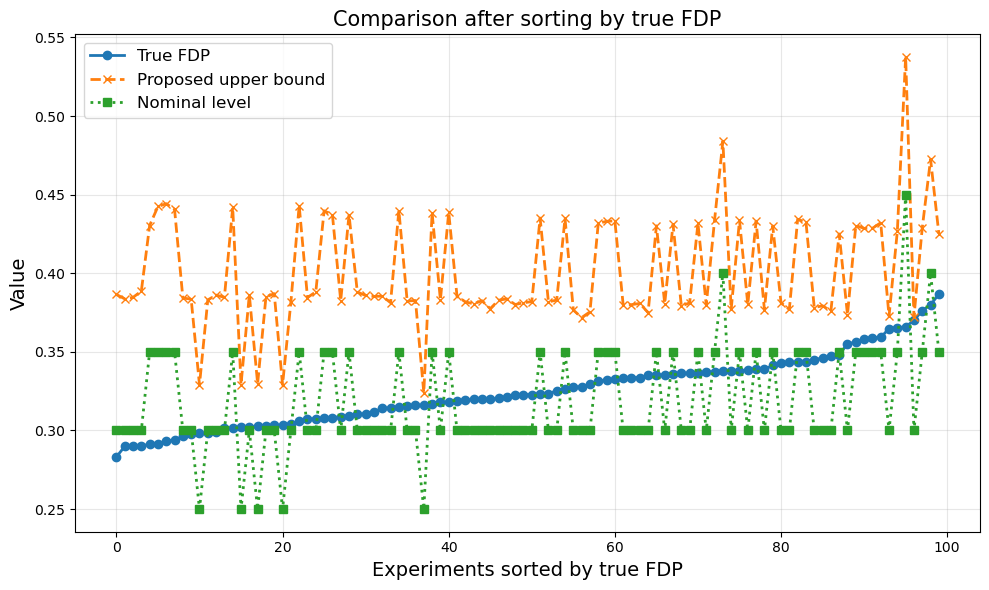

In [ ]:
true_fdp = experiments_df["FDP_BH"].to_numpy()
upper = np.minimum(experiments_df["FDP_BH_upper_bound"].to_numpy(), 1.0)
nominal = np.asarray(alphas_bh)

order = np.argsort(true_fdp)

plt.figure(figsize=(10, 6))
plt.plot(true_fdp[order], label="True FDP", lw=2, marker="o")
plt.plot(upper[order], label="Proposed upper bound", lw=2, linestyle="--", marker="x")
plt.plot(nominal[order], label="Nominal level", lw=2, linestyle=":", marker="s")

plt.xlabel("Experiments sorted by true FDP", fontsize=14)
plt.ylabel("Value", fontsize=14)
plt.title("Comparison after sorting by true FDP", fontsize=15)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Coverage of proposed upper bound: 1.000
Coverage of selected BH level:    0.380
Mean gap (upper - true):          0.075
Mean gap (BH level - true):       -0.007
Median gap (upper - true):        0.073
Median gap (BH level - true):     -0.010


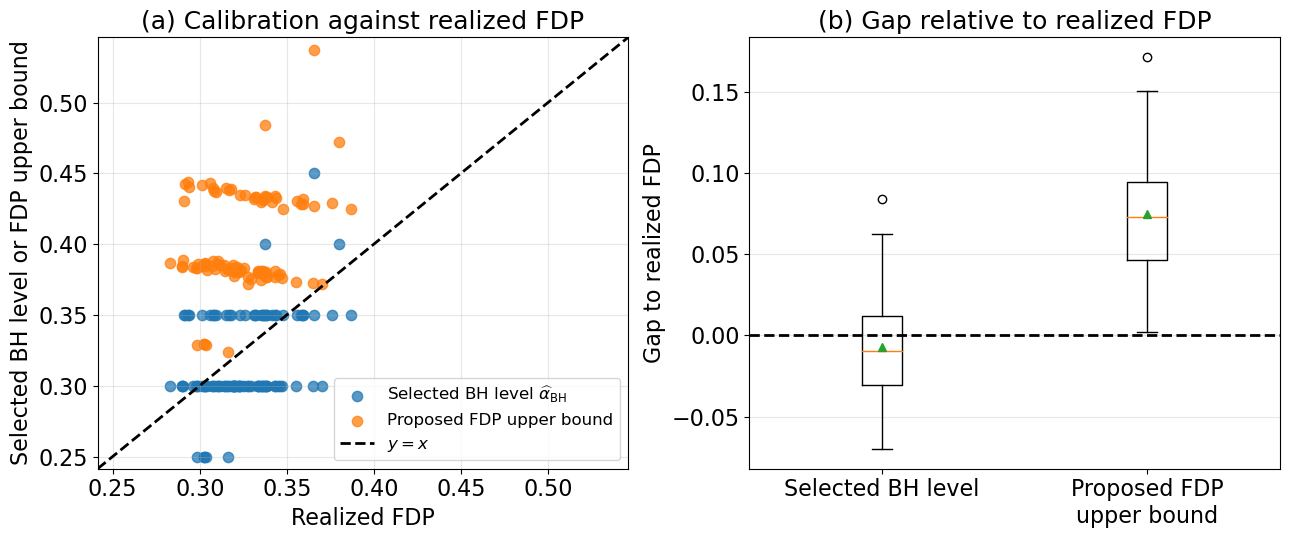

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Inputs
true_fdp = experiments_df["FDP_BH"].to_numpy()
upper = np.minimum(experiments_df["FDP_BH_upper_bound"].to_numpy(), 1.0)
nominal = np.asarray(alphas_bh)

# Basic summaries
gap_upper = upper - true_fdp
gap_nominal = nominal - true_fdp

cover_upper = np.mean(gap_upper >= 0)
cover_nominal = np.mean(gap_nominal >= 0)

mean_gap_upper = np.mean(gap_upper)
mean_gap_nominal = np.mean(gap_nominal)

median_gap_upper = np.median(gap_upper)
median_gap_nominal = np.median(gap_nominal)

print(f"Coverage of proposed upper bound: {cover_upper:.3f}")
print(f"Coverage of selected BH level:    {cover_nominal:.3f}")
print(f"Mean gap (upper - true):          {mean_gap_upper:.3f}")
print(f"Mean gap (BH level - true):       {mean_gap_nominal:.3f}")
print(f"Median gap (upper - true):        {median_gap_upper:.3f}")
print(f"Median gap (BH level - true):     {median_gap_nominal:.3f}")

# ---------- Figure ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ---------------- Panel 1: calibration scatter ----------------
ax = axes[0]

mn = min(true_fdp.min(), upper.min(), nominal.min())
mx = max(true_fdp.max(), upper.max(), nominal.max())
pad = 0.03 * (mx - mn + 1e-12)
lo, hi = mn - pad, mx + pad

ax.scatter(
    true_fdp, nominal,
    alpha=0.75, s=55,
    label=r"Selected BH level $\widehat{\alpha}_{\mathrm{BH}}$"
)
ax.scatter(
    true_fdp, upper,
    alpha=0.75, s=55,
    label="Proposed FDP upper bound"
)
ax.plot([lo, hi], [lo, hi], "k--", lw=2, label=r"$y=x$")
fs = 16
ax.set_xlabel("Realized FDP", fontsize=fs)
ax.set_ylabel("Selected BH level or FDP upper bound", fontsize=fs)
ax.set_title("(a) Calibration against realized FDP", fontsize=18)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.tick_params(axis="both", labelsize=fs)
ax.legend(fontsize=fs-4)
ax.grid(True, alpha=0.3)

# ax.text(
#     0.04, 0.96,
#     f"Coverage, proposed bound: {cover_upper:.2f}\n"
#     f"Coverage, selected BH level: {cover_nominal:.2f}",
#     transform=ax.transAxes,
#     va="top",
#     fontsize=12,
#     bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
# )

# ---------------- Panel 2: gap distribution ----------------
ax = axes[1]

gap_df = pd.DataFrame({
    r"Selected BH level $\widehat{\alpha}_{\mathrm{BH}}$": gap_nominal,
    "Proposed FDP upper bound": gap_upper,
})

ax.boxplot(
    [gap_nominal, gap_upper],
    labels=[
        r"Selected BH level",
        "Proposed FDP\nupper bound"
    ],
    showmeans=True
)

ax.axhline(0, color="black", linestyle="--", lw=2)
ax.set_ylabel("Gap to realized FDP", fontsize=fs)
ax.set_title("(b) Gap relative to realized FDP", fontsize=18)
ax.tick_params(axis="both", labelsize=fs)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    Path("all_figures") / "BH_better_visualization.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()


In [ ]:

results = []

for idx, row in experiments_df.iterrows():
    fdps = np.array(row['FDPs'])
    fdp_simulation = np.array(row['FDP_simulation'])
    
    # Check if FDP_simulation is always greater than or equal to FDPs
    is_always_larger = np.all(fdp_simulation >= fdps)
    results.append(is_always_larger)

# Displaying or saving the dataframe
print(sum(results))


92


500


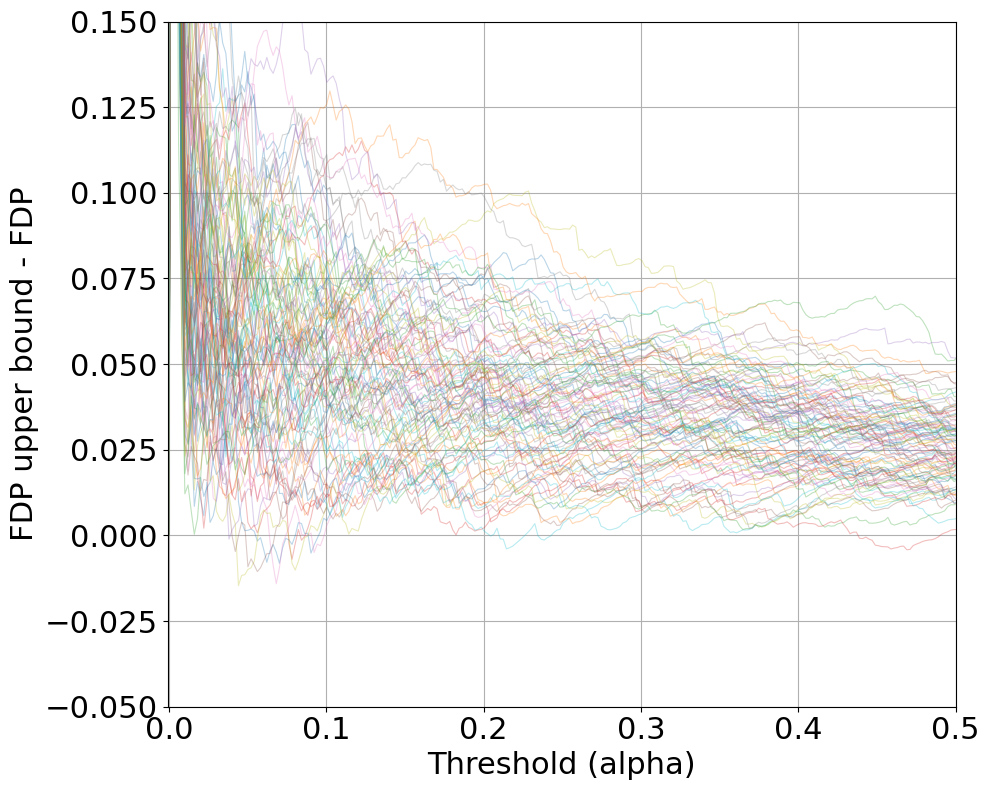

In [17]:
grid = np.linspace(0, 1, 500)
print(grid.size)
# Plotting the differences for each of the 100 experiments
plt.figure(figsize=(10, 8))

for idx, row in experiments_df.iterrows():
    # Assuming each value in the columns is a list of FDP values for the corresponding grid points
    fdps = np.array(row['FDPs'])
    fdp_simulation = np.array(row['FDP_simulation'])
    difference = fdp_simulation - fdps
    plt.plot(grid, difference, alpha=0.3, linewidth=0.8)  # Plot with some transparency for better visualization

plt.xlabel('Threshold (alpha)', fontsize=22)
plt.ylabel('FDP upper bound - FDP', fontsize=22)
plt.grid(True)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

plt.xlim(-0.001, 0.5)
plt.ylim(-0.05, 0.15)
plt.tight_layout()
plt.savefig(Path('all_figures')/'intro_b.pdf', format = 'pdf')
plt.show()

# Single Experiment

In [10]:
test_data = pd.read_csv('test_199.csv')
calib_data = pd.read_csv('calib_199.csv')
test_data.rename(columns={'test_pred': 'pred', 'test_true': 'true'}, inplace=True)
calib_data.rename(columns={'calib_pred': 'pred', 'calib_true': 'true'}, inplace=True)
all_data = pd.concat([calib_data, test_data], ignore_index=True)
n = calib_data.shape[0]
m = test_data.shape[0]
n_total = m+n

upper_MC_HC = uniform_ecdf_upper_bound(n = n, m = m, delta= 0.1, lower = 0.01, upper = 0.5, method = 'MC-THC')

def V(yhat, y, c):
    return 10 * y - yhat

def V(yhat, y, c):
    M = 10  # Large constant M
    return M * (y > c) + c * (y <= c) - yhat


# def V(x,y):
#     return y-x
### compute (true) FDP if reject all pval < alpha
def FDP(alpha, pvals, truth):
    R = sum(pvals <= alpha)
    FR = R - sum(truth[pvals<=alpha])
    return FR/np.maximum(R,1)

grid = np.linspace(0,1,10000)


#np.random.seed(123) 
shuffled_indices = np.random.permutation(n_total)
test_indices = shuffled_indices[:m]
calib_indices = shuffled_indices[m:]
test_data = all_data.iloc[test_indices].reset_index(drop=True)
calib_data = all_data.iloc[calib_indices].reset_index(drop=True)

# set the threshold as the 70th percentile

test_score = V(test_data['pred'].values, test_data['q8'].values, test_data['q8'].values)
calib_score = V(calib_data['pred'].values, calib_data['true'].values, calib_data['q8'].values)
## conformal p value
#pvals = (np.random.rand(m) + np.sum(calib_score[:, None] < test_score[None, :], axis=0)) / (n + 1)
pvals = np.zeros(m)
for idx in range(m):
    pvals[idx] = (np.random.rand(1)* (1+np.sum( calib_score == test_score[idx])) + np.sum( calib_score < test_score[idx]))/(n+1)
_, rejection_threshold = benjamini_hochberg(pvals)

T = len(grid)
FDPs = np.zeros(T)
FDP_estimation = np.zeros(T)
non_nulls = test_data['true'] > test_data['q8']
non_nulls = non_nulls.astype(int)
for i in range(T):
    FDPs[i] = FDP(grid[i], pvals, non_nulls)
    FDP_estimation[i] = m * grid[i]/np.maximum(sum(pvals <= grid[i]),1)
FDP_THC = uniform_FDP_upper_bound(pvals, n = n, m = m, delta= 0.1, lower = 0.01, upper = 0.5, method = 'MC-THC', boost = True)(grid)
FDP_HC = uniform_FDP_upper_bound(pvals, n = n, m = m, delta= 0.1, lower = 0.01, upper = 0.5, method = 'MC-HC', boost = True)(grid)
FDP_KS = uniform_FDP_upper_bound(pvals, n = n, m = m, delta= 0.1, lower = 0.01, upper = 0.5, method = 'MC-KS', boost = True)(grid)
FDP_baseline = uniform_FDP_upper_bound(pvals, n = n, m = m, delta= 0.1, lower = 0.01, upper = 0.5, method = 'KS', boost = True)(grid)
FDP_BJ = uniform_FDP_upper_bound(pvals, n = n, m = m, delta= 0.1, lower = 0.01, upper = 0.5, method = 'MC-BJ', boost = True)(grid)




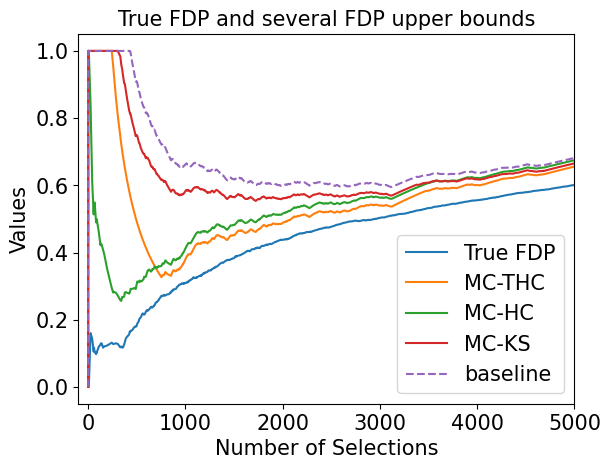

In [11]:
# Calculate number of rejections for each threshold
num_rejections = np.array([np.sum(pvals <= t) for t in grid])

plt.plot(num_rejections, FDPs, label='True FDP')
#plt.plot(grid, FDP_estimation, label='Estimation',linestyle='--')
plt.plot(num_rejections, FDP_THC, label='MC-THC')
plt.plot(num_rejections, FDP_HC, label='MC-HC')
plt.plot(num_rejections, FDP_KS, label='MC-KS')
#plt.plot(grid, FDP_BJ, label='MC-BJ')
plt.plot(num_rejections, FDP_baseline, label='baseline', linestyle='--')
#plt.plot(grid, FDP_marginal, label='marginal', linestyle='--')

fs = 15
plt.xlabel('Number of Selections', fontsize=fs)
plt.ylabel('Values', fontsize=fs)
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
plt.xlim(-100, 5000)
plt.title('True FDP and several FDP upper bounds', fontsize=fs)
plt.legend(fontsize=fs)

plt.savefig(Path('all_figures')/'intro_a.pdf', format = 'pdf')
plt.show()